In [1]:
import catalogue_analysis as ca
import numpy as np
from astropy.table import join,Table,Column,vstack
from astropy.io import fits
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.313, Tcmb0=2.725)   #Standard Planck Cosmology in Mpc/h units
from kcorrections  import DESI_KCorrection

In [2]:

# Specify regions to loop over
regions=('S','N')
#
# Read the enhanced BGS catalogue produced by Augment_BGS_cat.ipynb
dat=Table.read('sdata/BGS_Y3_27Feb2026.fits')

print('Meta data stored with ths table:')
print(dat.meta)
#
# Check selection cuts agree with stored meta data of the sample we have read
ca.CheckParametersMatch

dat.info('stats')

Meta data stored with ths table:
OrderedDict([('EXTNAME', 'LSS'), ('QEVOL_N', 0.78), ('QG_N', 0.91), ('QR_N', 0.78), ('QZ_N', 0.45), ('QW1_N', 0.7), ('ZMAX_N', 0.6), ('ZMIN_N', 0.002), ('BRIGHT_N', 12.0), ('FAINT_N', 19.54), ('AREA_N', 0.09278121822233744), ('F_RAN_N', 1.0), ('COL_N', 'blue'), ('STYLE_N', 'dashed'), ('QEVOL_S', 0.78), ('QG_S', 0.91), ('QR_S', 0.78), ('QZ_S', 0.45), ('QW1_S', 0.7), ('ZMAX_S', 0.6), ('ZMIN_S', 0.002), ('BRIGHT_S', 12.0), ('FAINT_S', 19.5), ('AREA_S', 0.2067143725378028), ('F_RAN_S', 1.0), ('COL_S', 'red'), ('STYLE_S', 'solid'), ('H0', 100.0), ('TCMB0', 2.725), ('OM0', 0.313), ('PMATCH', False)])
<Table length=7874903>
       name            mean         std         min          max    
------------------ ------------ ----------- ------------ -----------
          TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16
            TILEID      23114.2     1881.87        20000       27852
                 Z     0.213345    0.104259   0.00200098     0.599

In [3]:
# Read one the corresponding Y3 random (It is matched to the orginal clustering catalogue and not yet the cuts made to our sample
fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_7_clustering.ran.fits'
ranfull=ca.Y3load_catalogues(fpath)
ran=ranfull['RA','DEC','PHOTSYS']
del ranfull
ran['reg']=ran['PHOTSYS'] #give the name my code expects
ran.info('stats')



<Table length=30890761>
  name    mean    std       min       max  
------- ------- ------- ----------- -------
     RA 182.362 93.1026 1.44426e-05     360
    DEC 22.0439 23.2156    -19.5674 79.2522
PHOTSYS      --      --          --      --
    reg      --      --          --      --


In [4]:
# Apply restrictive limits to the [zmin,zmax] range and recompute the corresponding [vmin,vmax]
dz = 0.03
dat['zmin'] = np.clip(dat['zmin'], a_min=dat['Z']-dz, a_max=np.inf)
dat['zmax'] = np.clip(dat['zmax'], a_min=-np.inf, a_max=dat['Z']+dz)

#Add vmin,vmax computer from zmin zmax
ca.add_vminvmax(dat,regions)  

starting region  S
starting region  N


In [5]:
# Construct a random catalogue by redistributing genuine galaxies within their Vmax volume and
# assigning them RA and DEC from an official DESI random catalogue

def random_catalogue(ran,dat,regions,nsamp=4,nbins=2000,nzbins=20):
    """Generate a random catalogue from the genuine catalogue and random RA and DEC using the method of Cole (MNRAS 2011) """
    # nsamp = how many times to clone each galaxy (modulated by the weigths)
    # nbins= number of volume bins
    # nzbins = number of redshift bins (just for plots)
    #
    #We are using V as the radial coordinate with V=0 corresponding to vmin_sample.
    #But the dat['v'] value of each galaxies is relative to its own dat['vmin'] which for some of the bright galaxies
    #can be greater than vmin_sample.
    #So for our V coordinate we have to add back on dat['vmin'] and subtract vmin_sample
    # Then we also have to take account dat['vmin'] >vmin_sample when placing their clones.


    #dat['WEIGHT']=dat['WEIGHT']*0.0+1.0 #????? hack to remove weights for now



    for reg in regions:           #Do regions separately (Would have to define volume bins differently to merge)
      print('starting region ',reg)
      regmask=(dat['reg']==reg)#mask to select objects in specified region

      Sel=ca.selection(reg)
      #minimum vmin for the whole selected sample. We just consider volume above this vmin and work in bins of that covering 0 to vmax-vmin
      vmin_sample=Sel['area']*(4.0*np.pi/3.0)*(cosmo.comoving_distance(Sel['zmin']).value)**3 
      vmax_sample=Sel['area']*(4.0*np.pi/3.0)*(cosmo.comoving_distance(Sel['zmax']).value)**3 - vmin_sample
      
      vbins=np.linspace(0.0,vmax_sample,nbins) # volume bin edges
      vbin_width=vbins[1]-vbins[0] #bin width
      print('vbin_width:',vbin_width*1.0e-09,'(Gpc/h)^3')  
      vbin_cen=(vbins[:-1]+vbins[1:])/2.0 #volume bin centres
      Delta_vbin=np.ones(vbin_cen.size)  #Overdensity in each volume bin initialised to uniform density
      Delta=np.ones(dat['Z'].size)       #Overdensity for each galaxy initialised to uniform density
      v=np.zeros(dat['Z'].size)          #initialise array for random volume values for each galaxy 
      zbins=np.linspace(Sel['zmin'],Sel['zmax'],nzbins) # zbin edges (used for plots)
      zbin_cen=(zbins[:-1]+zbins[1:])/2.0 #zbin centres

      # For top axis of some plots we set up a grid of redshift tick marks and compute their volume coordinate
      zgrid=np.linspace(0.1,Sel['zmax'],5)
      zgrid_strings = ["%.1f" % number for number in zgrid] #convert to strings rounded to 1 decimal place
      vgrid=Sel['area']*(4.0*np.pi/3.0)*(cosmo.comoving_distance(zgrid).value)**3 - vmin_sample

      #Check that data values are all in expected ranges
      vcheck=  vmax_sample-dat['v'][regmask]
      if (np.min(vcheck)<0): print('ERROR: object with V>V_max')
      vcheck=  vbins[nbins-1]- (dat['v'][regmask]+dat['vmin'][regmask]-vmin_sample)
      if (np.min(vcheck)<0): print('ERROR: object with V+vmin-vmin_sample> largest vbin edge')
      vcheck=  (dat['v'][regmask]+dat['vmin'][regmask]-vmin_sample)
      if (np.min(vcheck)<0): print('ERROR: object with V+vmin<vmin_sample')
      vcheck=  (dat['vmin'][regmask]-vmin_sample)
      if (np.min(vcheck)<0): print('ERROR: object with vmin<vmin_sample')
      zcheck=  (dat['zmin'][regmask]-Sel['zmin'])
      if (np.min(zcheck)<0): print('ERROR: object with zmin<zmin_sample')

      # Plot the number of galaxies per volume  (and redshift) bin  (This will increase towards low volume as there we see fainter galaxies)
      print('Plots of the number of galaxies per volume and redshift bin in the original catalogue:')  
      vhist_dat,_=np.histogram((dat['v'][regmask]+dat['vmin'][regmask]-vmin_sample),bins=vbins,weights=dat['WEIGHT'][regmask]) #data histogram in volume coordinate bins
      zhist_dat,_=np.histogram(dat['Z'][regmask],bins=zbins,weights=dat['WEIGHT'][regmask])


      #Add fancy redshift labels for the top axis
      ax = host_subplot(211)
      ax2 = ax.twin()
      ax2.set_xlabel('$z$')    
      ax2.xaxis.set_label_position('top') 
      ax2.set_xticks(vgrid,labels=zgrid_strings)   
      ax.plot(vbin_cen,np.log10(np.maximum(vhist_dat,1.0e-10)))
      plt.xlim([0,vmax_sample])  
      plt.ylim([0,6.0])
      plt.xlabel('$V /(Mpc/h)^3$')
      plt.ylabel('$log_{10}$ N(V)')
      ax3 = host_subplot(212)
      ax3.plot(zbin_cen,np.log10(np.maximum(zhist_dat,1.0e-10)))
      plt.xlabel('$z$')
      plt.ylabel('$log_{10}$ N(z)')
      plt.show()

      n=np.zeros(dat['Z'].size, dtype=int)        #initialise number of clones of each galaxy to zero
      iv=np.zeros(dat['Z'].size, dtype=int)       
      iv[regmask]=np.digitize(dat['v'][regmask]+dat['vmin'][regmask]-vmin_sample,vbins)-1 #find the volume bin index for each galaxy  

      # For each iteration we will plot the run od overdensity with redshift and volume coordinates
      # To do so we first set up the fancy redshift labels for the top axis
      ax = host_subplot(111)
      ax2 = ax.twin()
      ax2.set_xlabel('$z$')    
      ax2.xaxis.set_label_position('top') 
      ax2.set_xticks(vgrid,labels=zgrid_strings)  


      #Main iteration loop
      for j in range(5): #loop until Deltas converge within Poisson Errors???? -- just loops 2 times for now
        print('starting iteration',j)
        nmean=nsamp*dat['WEIGHT']/Delta #mean number of times to redistribute each galaxy
        print('mean and RMS of nmean number of clones:',np.mean(nmean),np.sqrt(np.mean(((nmean-np.mean(nmean))**2))))
        n=np.floor(nmean).astype(int) #Round down to the nearest integer 
        mask= ( np.random.uniform(size=Delta.size) < nmean-n) #Choose with probability equal to how much nmean exceeds n those for which n is to be increased by 1
        print('mask',mask.sum())  
        cmask=mask&regmask #combined mask for region and those needing extra increment 
        print('cmask:',len(cmask),cmask.sum())  
        n[cmask] += 1 # increment if nmean>n with probability such that <n>=nmean for those in the region
        nmax=n.max() #  the maximum number of times any galaxy will be cloned
        vhist=np.zeros(vhist_dat.size) # initialize vhist histogram of the number of clones in each volume bin
        for i in range(nmax): #loop over the maximum number of times we need to clone any galaxy
            mask= (i<n) #add a clone of all the galaxies that need i or more clones (remember i starts from 0)
            cmask=mask&regmask #combined region and those needing incrementing mask
            nclones=np.count_nonzero(cmask) #this is the total number of galaxies we are cloning on this pass
            #print('pass:',i+1,'of',nmax,' extra clones added:',nclones)
            v[cmask]=dat[cmask]['vmax']*np.random.uniform(size=nclones)# distribute each clone uniformly within its vmax
            hist,vbinss=np.histogram(v[cmask]+dat[cmask]['vmin']-vmin_sample,bins=vbins) #bin the clones in volume coordinate bins
            vhist += hist  # increment the histogram with the clones from this pass
        # Now we have cloned and binned all the galaxies we can compute the overdensity Delta in each volume coordinate bin    
        binmask = (vhist>0)  #mask to avoid divide by zero in any bin with no clones 
        Delta_vbin[binmask]=nsamp*vhist_dat[binmask]/vhist[binmask] #overdensity relative to clones
        Delta_vbin=Delta_vbin/np.mean(Delta_vbin)  #Renormalize the mean which is necessary as <nmean>.ne.nsamp as <1/Delta>.ne.1
        print('RMS Delta:',np.sqrt(np.mean(((Delta_vbin-np.mean(Delta_vbin))**2))))
        plt.plot(vbin_cen,Delta_vbin,label=str(j))# plot overdensity at this iteration  
        Delta[regmask]=Delta_vbin[iv[regmask]] # update each galaxy's overdensity (for galaxies in the region)
          
        # Go back and do next iteration    
      #
      #Finish off the plot of the run of overdensity to see how well convergence has worked
      plt.xlim([0,vmax_sample])
      plt.ylabel('$Overdensity\ \Delta$')
      plt.xlabel('$V$')
      ax.legend(loc='upper left')
      plt.show()


    # Now need to assign random cloned galaxies to the RA and DEC of the random catalogue
    # We should pick each galaxy with a probabilty proportional to dat['WEIGHT']/Delta 
    # we then assign it a redshift by randomly placing it within its Vmax.
    # Finally we need to recompute its apparent magnitudes at this redshift
    print('Assigning random cloned galaxies to RA and DECS of the random catalogue')
    nran = ran['RA'].size
    ran['ABSMAG_RP1']=np.zeros(nran)
    ran['ABSMAG_GP1']=np.zeros(nran)
    ran['v']=np.zeros(nran)
    ran['Z']=np.zeros(nran)
    ran['rmag']=np.zeros(nran)
    ran['gmag']=np.zeros(nran)
    for reg in regions: 
        print('starting region ',reg)
        Sel=ca.selection(reg)
        regmask=(dat['reg']==reg)
        ranregmask=(ran['PHOTSYS']==reg)
        #define the probability of cloning each galaxies
        prob=(dat['WEIGHT'][regmask]/Delta[regmask])/np.sum(dat['WEIGHT'][regmask]/Delta[regmask])
     
        nran = ran['RA'][ranregmask].size #number of objects in this region in the random catalogue
        chosen_indices = np.random.choice(dat['WEIGHT'][regmask].size, size=nran, p=prob) #choose galaxies to clone
        ran['ABSMAG_RP1'][ranregmask]=dat['ABSMAG_RP1'][regmask][chosen_indices] #copy absolute magnitudes
        ran['ABSMAG_GP1'][ranregmask]=dat['ABSMAG_GP1'][regmask][chosen_indices]
        ran['v'][ranregmask]=dat[regmask][chosen_indices]['vmin']+dat[regmask][chosen_indices]['vmax']*np.random.uniform(size=nran)#copy volume cordinate 
        zgrid=np.linspace(0.0,Sel['zmax'],1000) #define a redshift grid at which we compute the volume coordinate
        vgrid=Sel['area']*(4.0*np.pi/3.0)*(cosmo.comoving_distance(zgrid).value)**3    
        ran['Z'][ranregmask]=np.interp(ran['v'][ranregmask],vgrid,zgrid) #use grid to interpolate redshift from volume coordinate
        DMOD=25.0+5.0*np.log10(cosmo.luminosity_distance(ran['Z'][ranregmask]).value) #compute distance modulus
        rest_GMR= ran['ABSMAG_GP1'][ranregmask]- ran['ABSMAG_RP1'][ranregmask]  #rest frame colour
        kcorr_r  = DESI_KCorrection(band='R', file='jmext', photsys=reg)   #set up r-band k-correction
        Qr=Sel['Qr']  #compute r-band magnitude using appropriate k+e correction
        ran['rmag'][ranregmask]=ran['ABSMAG_RP1'][ranregmask]+DMOD-Qr*(ran['Z'][ranregmask]-0.1)+kcorr_r.k(ran['Z'][ranregmask],rest_GMR)
        kcorr_g  = DESI_KCorrection(band='G', file='jmext', photsys=reg)  #set up g-band k-correction
        Qg=Sel['Qg'] #compute g-band magnitude using appropriate k+e correction
        ran['gmag'][ranregmask]=ran['ABSMAG_GP1'][ranregmask]+DMOD-Qg*(ran['Z'][ranregmask]-0.1)+kcorr_g.k(ran['Z'][ranregmask],rest_GMR)
     


    return




starting region  S
vbin_width: 0.0015708810622187357 (Gpc/h)^3
Plots of the number of galaxies per volume and redshift bin in the original catalogue:


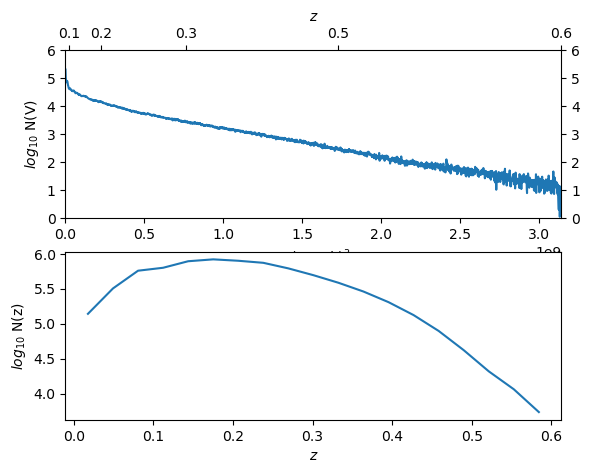

starting iteration 0
mean and RMS of nmean number of clones: 5.217268098408155 3.1611779503284496
mask 290814
cmask: 7874903 197232
pass: 1 of 297  extra clones added: 5436052
pass: 2 of 297  extra clones added: 5436052
pass: 3 of 297  extra clones added: 5436052
pass: 4 of 297  extra clones added: 5436052
pass: 5 of 297  extra clones added: 1165793
pass: 6 of 297  extra clones added: 1028141
pass: 7 of 297  extra clones added: 1017949
pass: 8 of 297  extra clones added: 1013893
pass: 9 of 297  extra clones added: 384452
pass: 10 of 297  extra clones added: 350015
pass: 11 of 297  extra clones added: 346483
pass: 12 of 297  extra clones added: 345040
pass: 13 of 297  extra clones added: 148210
pass: 14 of 297  extra clones added: 135045
pass: 15 of 297  extra clones added: 133564
pass: 16 of 297  extra clones added: 132827
pass: 17 of 297  extra clones added: 62639
pass: 18 of 297  extra clones added: 56983
pass: 19 of 297  extra clones added: 56127
pass: 20 of 297  extra clones added:

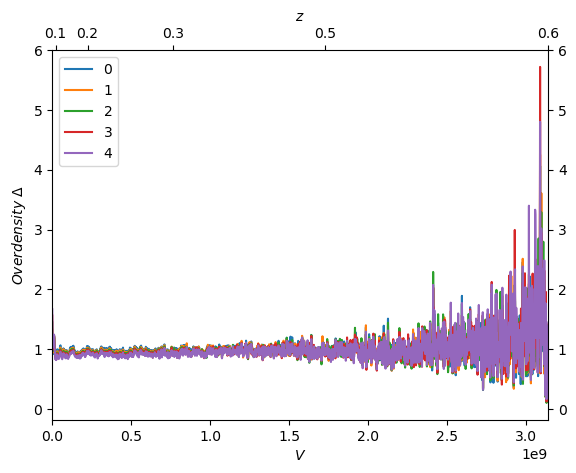

starting region  N
vbin_width: 0.0007050707546152849 (Gpc/h)^3
Plots of the number of galaxies per volume and redshift bin in the original catalogue:


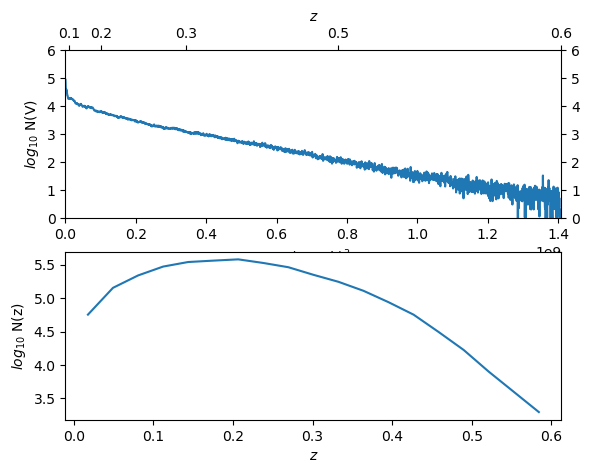

starting iteration 0
mean and RMS of nmean number of clones: 5.217268098408155 3.1611779503284496
mask 290637
cmask: 7874903 93540
pass: 1 of 296  extra clones added: 2438851
pass: 2 of 296  extra clones added: 2438851
pass: 3 of 296  extra clones added: 2438851
pass: 4 of 296  extra clones added: 2438851
pass: 5 of 296  extra clones added: 516492
pass: 6 of 296  extra clones added: 449680
pass: 7 of 296  extra clones added: 444325
pass: 8 of 296  extra clones added: 442330
pass: 9 of 296  extra clones added: 168495
pass: 10 of 296  extra clones added: 152965
pass: 11 of 296  extra clones added: 151101
pass: 12 of 296  extra clones added: 150091
pass: 13 of 296  extra clones added: 64675
pass: 14 of 296  extra clones added: 58638
pass: 15 of 296  extra clones added: 57913
pass: 16 of 296  extra clones added: 57557
pass: 17 of 296  extra clones added: 26800
pass: 18 of 296  extra clones added: 24217
pass: 19 of 296  extra clones added: 23859
pass: 20 of 296  extra clones added: 23675
pa

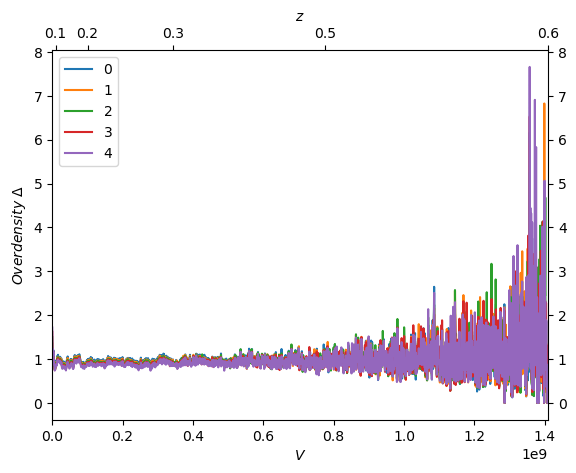

Assigning random cloned galaxies to RA and DECS of the random catalogue
starting region  S
Reading k-correction polynomials from  .//data//jmext_kcorr_S_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_S_gband_z01.dat
starting region  N
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_N_gband_z01.dat


In [6]:
# Make random catalogue
random_catalogue(ran,dat,regions)

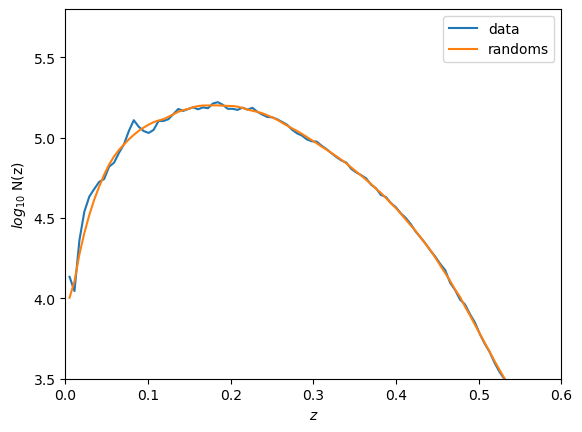

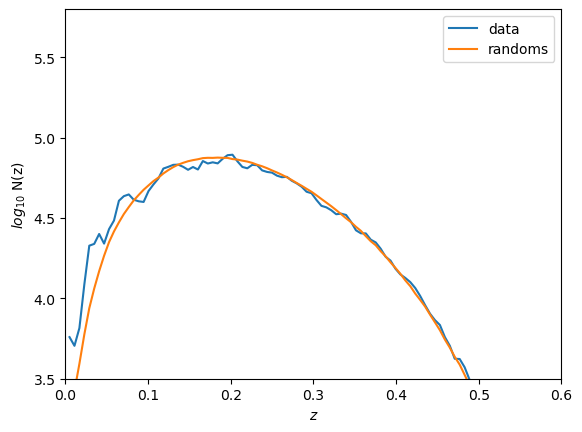

In [15]:
# Compare Genuine and Random Catalogue including volume limited subsets
nbins=100
for reg in regions:
    Sel=ca.selection(reg)
     
    regmask=(dat['reg']==reg)
    ranregmask=(ran['reg']==reg)
    fac_norm=dat['reg'][regmask].size/ran['reg'][ranregmask].size
    zhist_dat,zbins=np.histogram(dat['Z'][regmask],bins=100,weights=dat['WEIGHT'][regmask]) #data histogram in volume coordinate bins
    zbin_cen=(zbins[:-1]+zbins[1:])/2.0 #volume bin centres
    plt.plot(zbin_cen,np.log10(np.maximum(zhist_dat,1.0e-10)),label='data')

    zhist_ran,_=np.histogram(ran['Z'][ranregmask],bins=zbins) #data histogram in volume coordinate bins
    fac_norm=zhist_dat.sum()/zhist_ran.sum()
    zhist_ran=zhist_ran*fac_norm
    plt.plot(zbin_cen,np.log10(np.maximum(zhist_ran,1.0e-10)),label='randoms')
    
    plt.xlim([0,0.6])  
    plt.ylim([3.5,5.8])
    plt.xlabel('$z$')
    plt.ylabel('$log_{10}$ N(z)')
    plt.legend()
    plt.show()


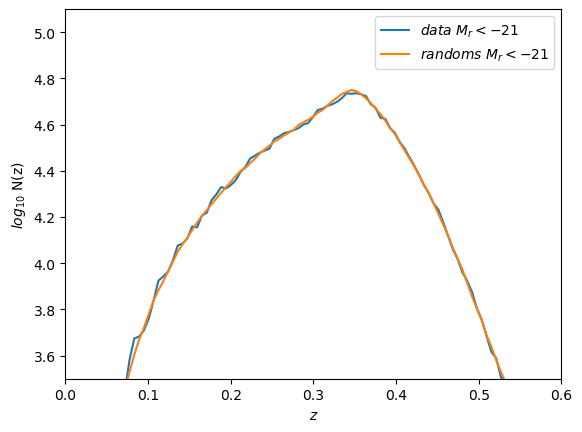

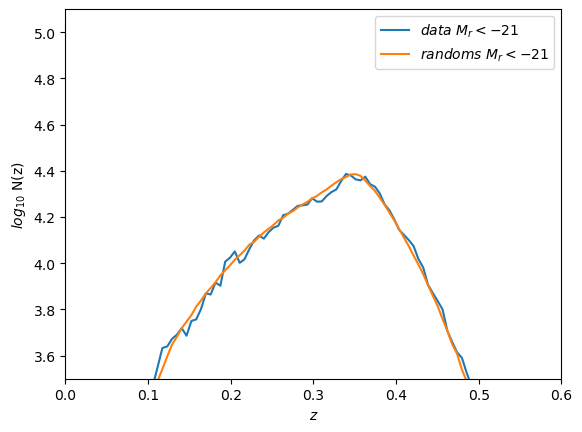

In [13]:
# Compare Genuine and Random Catalogue including volume limited subsets
nbins=100
for reg in regions:
    Sel=ca.selection(reg)
     
    regmask=(dat['reg']==reg)
    ranregmask=(ran['reg']==reg)
    
    
    regmask=(dat['reg']==reg) & (dat['ABSMAG_RP1']<-21)
    ranregmask=(ran['reg']==reg) & (ran['ABSMAG_RP1']<-21)
    
    zhist_dat,zbins=np.histogram(dat['Z'][regmask],bins=100,weights=dat['WEIGHT'][regmask]) #data histogram in volume coordinate bins
    zbin_cen=(zbins[:-1]+zbins[1:])/2.0 #volume bin centres
    plt.plot(zbin_cen,np.log10(np.maximum(zhist_dat,1.0e-10)),label='$data\ M_r<-21$')

    zhist_ran,_=np.histogram(ran['Z'][ranregmask],bins=zbins) #data histogram in volume coordinate bins
    fac_norm=zhist_dat.sum()/zhist_ran.sum()
    zhist_ran=zhist_ran*fac_norm
    plt.plot(zbin_cen,np.log10(np.maximum(zhist_ran,1.0e-10)),label='$randoms\ M_r<-21$')
    
    plt.xlim([0,0.6])  
    plt.ylim([3.5,5.1])
    plt.xlabel('$z$')
    plt.ylabel('$log_{10}$ N(z)')
    plt.legend()
    plt.show()


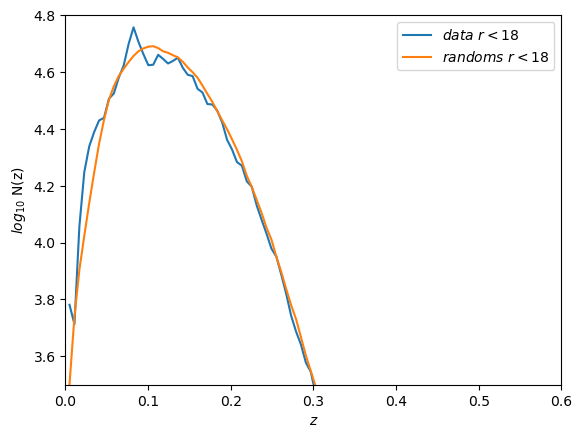

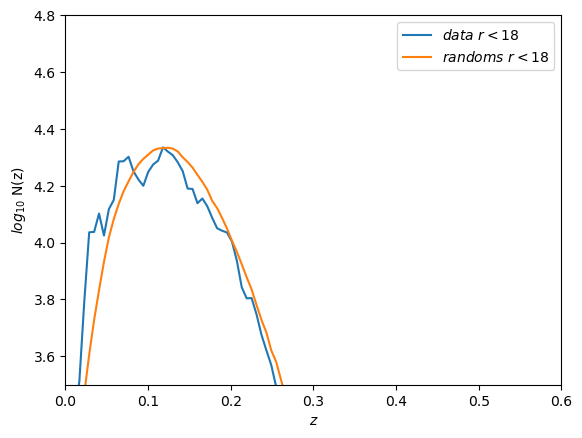

In [17]:
# Compare Genuine and Random Catalogue including volume limited subsets
nbins=100
for reg in regions:
    Sel=ca.selection(reg)
     
    regmask=(dat['reg']==reg)
    ranregmask=(ran['reg']==reg)
    fac_norm=dat['reg'][regmask].size/ran['reg'][ranregmask].size
    
    regmask=(dat['reg']==reg) & (dat['rmag']<18)
    ranregmask=(ran['reg']==reg) & (ran['rmag']<18)
    
    zhist_dat,zbins=np.histogram(dat['Z'][regmask],bins=100,weights=dat['WEIGHT'][regmask]) #data histogram in volume coordinate bins
    zbin_cen=(zbins[:-1]+zbins[1:])/2.0 #volume bin centres
    plt.plot(zbin_cen,np.log10(np.maximum(zhist_dat,1.0e-10)),label='$data\ r<18$')
    zhist_ran,_=np.histogram(ran['Z'][ranregmask],bins=zbins) #data histogram in volume coordinate bins
    fac_norm=zhist_dat.sum()/zhist_ran.sum()
    zhist_ran=zhist_ran*fac_norm
    plt.plot(zbin_cen,np.log10(np.maximum(zhist_ran,1.0e-10)),label='$randoms\ r<18$')
    
    plt.xlim([0,0.6])  
    plt.ylim([3.5,4.8])
    plt.xlabel('$z$')
    plt.ylabel('$log_{10}$ N(z)')
    plt.legend()
    plt.show()


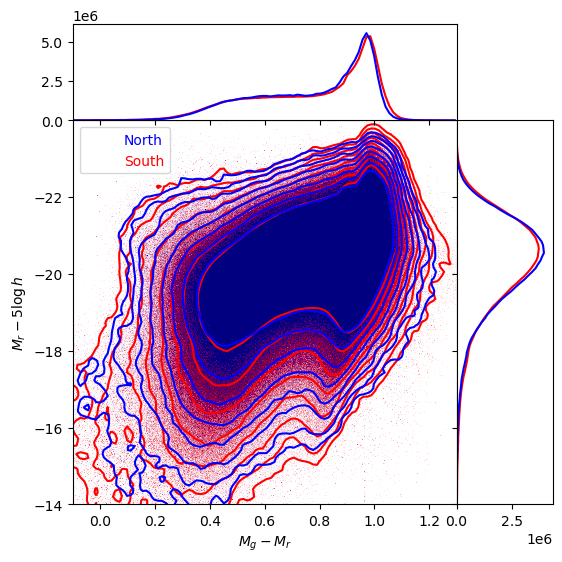

In [12]:
#colour-magnitude distributions
#ca.plot_col_mag(dat,regions)
ran['REST_GMR_0P1']=ran['ABSMAG_GP1']-ran['ABSMAG_RP1']
ca.plot_col_mag(ran,regions)

Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.
Using healpix map with NSIDE=32 and pixel area 3.357 sq.deg.


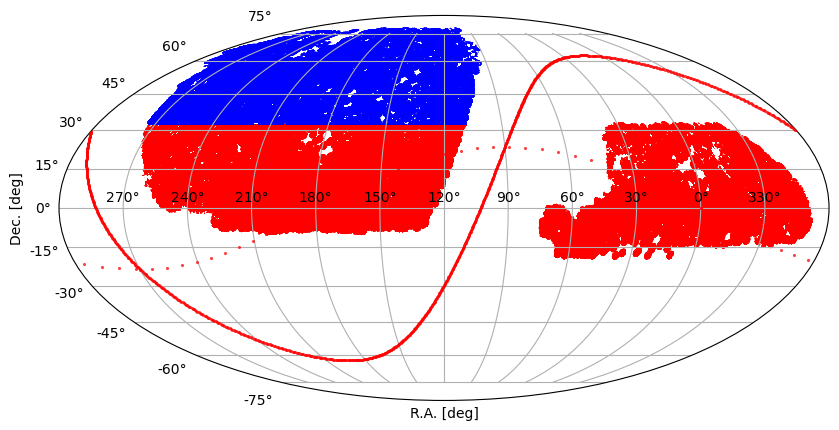

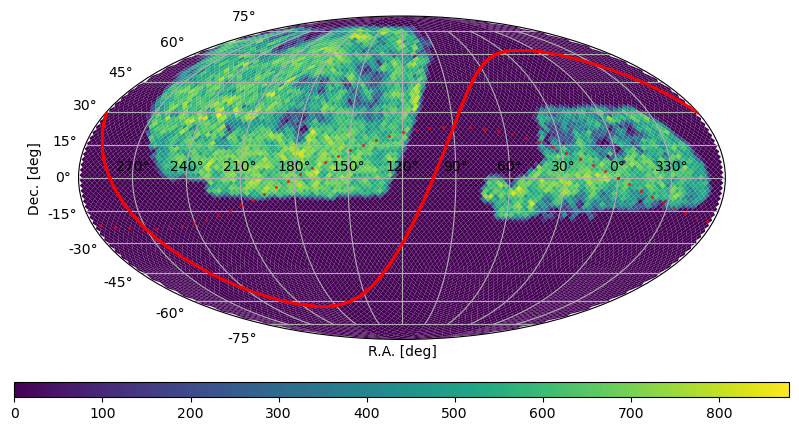

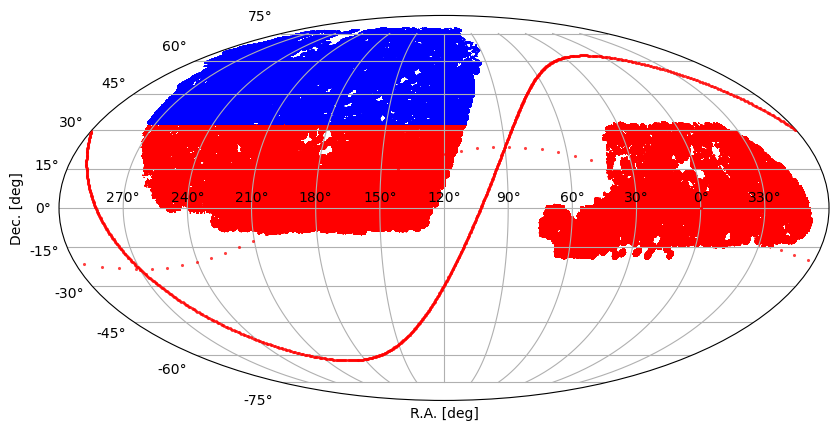

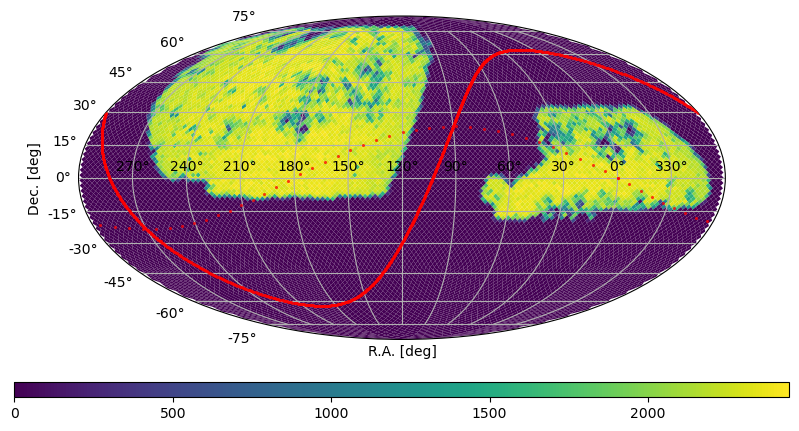

In [8]:
ca.sky_plot(dat,regions)
ca.sky_plot(ran,regions)